## ==========================================================
## 🧠 Hopify SaaS: Retained Customers by Segment Time-Series
## ==========================================================

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.tseries.offsets import DateOffset 

# ================================
# 📁 Set Base Path to Project Root
# ================================

try:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), "..", "..", ".."))
except NameError:
    # Jupyter or interactive context
    BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))

print("📁 Base path set to:", BASE_PATH)

## ==================================================
## 📥 Load & Clean Data
## ==================================================

In [2]:
file_path = os.path.join(
    BASE_PATH,
    "01_project_artifacts",
    "02_sql_output",
    "01_project_churn_retention_analysis",
    "07_hopify_retention_curve_signup_cohort.csv"
)

df = pd.read_csv(file_path)

# Clean column names
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("%", "percent")
)

# Rename to match plot expectations
df = df.rename(columns={
    'signup_cohort_month': 'cohort_month',
    'remaining_active_customers': 'retained_customers'
})

## ==================================================
## 📅 Format & Sort
## ==================================================

In [3]:
# Parse cohort month
df["cohort_month"] = pd.to_datetime(df["cohort_month"])

# Set consistent customer segment ordering
segment_order = ["Enterprise", "Mid-Market", "SMB"]
df["customer_segment"] = pd.Categorical(df["customer_segment"], categories=segment_order, ordered=True)


# ================================
# 📈 Plot: Retained Customers Over Time (Faceted)
# ================================

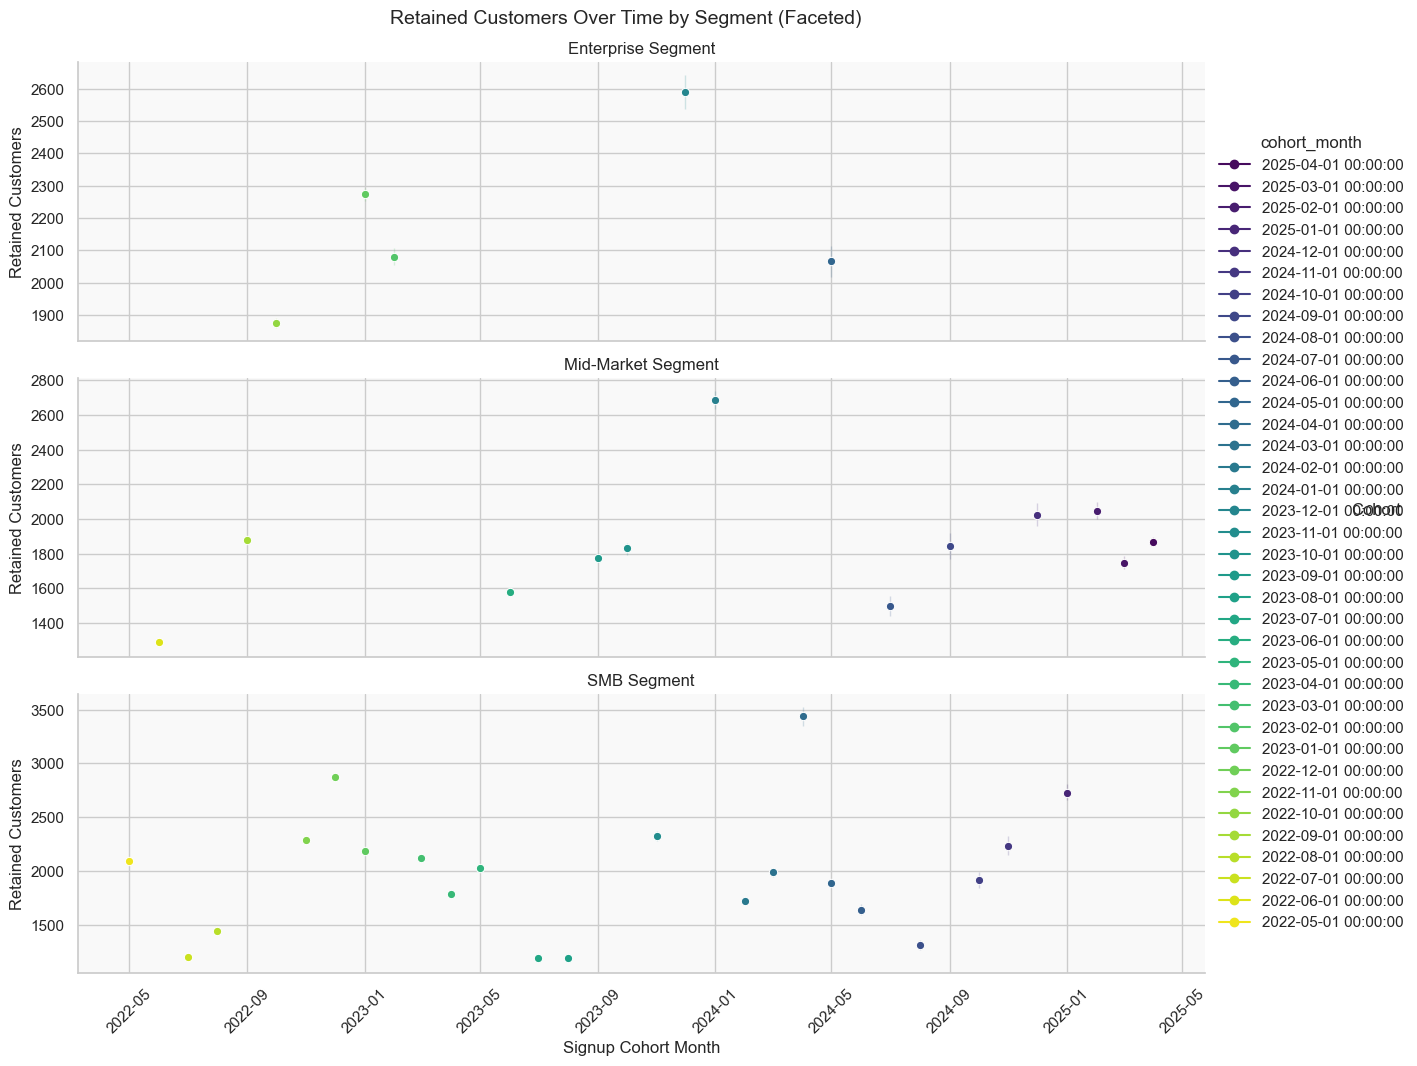

In [4]:
sns.set(style="whitegrid", rc={"axes.facecolor": "#F9F9F9"})
g = sns.relplot(
    data=df,
    kind="line",
    x="cohort_month",
    y="retained_customers",
    hue="cohort_month",
    row="customer_segment",
    marker="o",
    palette="viridis",
    height=3.5,
    aspect=3,
    facet_kws={"sharey": False}
)

g.set_titles("{row_name} Segment")
g.set_axis_labels("Signup Cohort Month", "Retained Customers")
g.fig.subplots_adjust(top=0.93)
g.fig.suptitle("Retained Customers Over Time by Segment (Faceted)", fontsize=14)
g.add_legend(title="Cohort", bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# ================================
# 💾 Save & Show
# ================================

In [5]:
output_path = os.path.join(
    BASE_PATH,
    "05_visuals",
    "hopify_retained_cust_over_time_seg_faceted.png"
)

plt.savefig(output_path, bbox_inches='tight')
plt.show()
print(f"✅ Chart saved to: {output_path}")

<Figure size 640x480 with 0 Axes>

✅ Chart saved to: /Users/jade.herman/Documents/00_github/hopify_saas_kpi_analysis/05_visuals/hopify_retained_cust_over_time_seg_faceted.png
